# Time series prediction models

Some content from:
https://www.kaggle.com/kashnitsky/topic-9-part-1-time-series-analysis-in-python

# Part 1

Let's look at real mobile game data. Specifically, we will look into ads watched per hour and in-game currency spend per day:

In [1]:
import matplotlib.pyplot as plt  
%matplotlib inline
from scipy.stats import norm

import warnings                                  # `do not disturb` mode
warnings.filterwarnings('ignore')
import random
import pandas as pd
import numpy as np  
from sklearn.model_selection import TimeSeriesSplit # you have everything done for you

ads = pd.read_csv('ads.csv', index_col=['Time'], parse_dates=['Time']).dropna()
currency = pd.read_csv('currency.csv', index_col=['Time'], parse_dates=['Time']).dropna()

In [2]:
import warnings                                  # `do not disturb` mode
warnings.filterwarnings('ignore')

**Note:** Since we have two different datasets (although related with the same problem), "ads" and "currency", in this notebook we will do something different than before: we apply each operation in the "ads" dataset, and you'll do the same on the "currency". You need to pay attention, because it's not always exactly the same thing, especially when the model starts to get complicated!

Let's start by plotting the time series

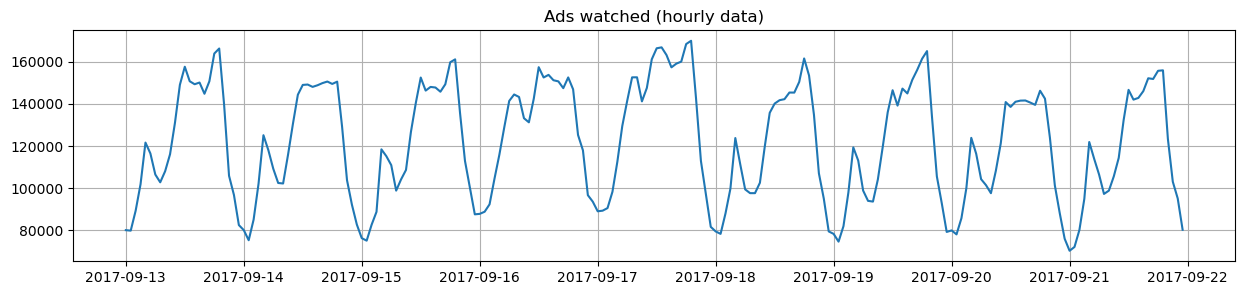

In [3]:
plt.figure(figsize=(15, 3))
plt.plot(ads.Ads)
plt.title('Ads watched (hourly data)')
plt.grid(True)
plt.show()

...and the histogram of the same variable

In [4]:
ads_mean=ads['Ads'].mean()
ads_std=ads['Ads'].std()
x_axis=np.arange(ads_mean-3*ads_std,ads_mean+3*ads_std, 100)

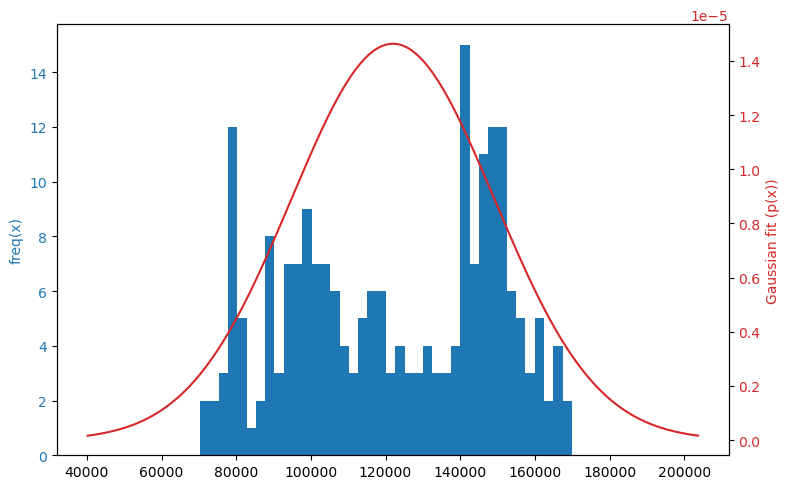

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_ylabel('freq(x)', color=color)  # we already handled the x-label with ax1
ax1.hist(ads['Ads'], bins=40, color=color)
ax1.tick_params(axis='y', labelcolor=color)


ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Gaussian fit (p(x))', color=color)
ax2.plot(x_axis, [norm.pdf(x, ads_mean, ads_std) for x in x_axis], color=color)
ax2.tick_params(axis='y', labelcolor=color)


fig.tight_layout()
plt.show()


We superimpose the normal fit, just to show that it's certainly not a Gaussian fit, maybe it is some mixture of two or three Gaussians?

Your turn to do the same with the other dataset

# Forecast quality metrics

Before we begin forecasting, let's understand how to measure the quality of our predictions and take a look at the most commonly used metrics.

We also add the mean absolute percentage error (MAPE) which is actually a popular one in Time series analysis

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In order to speed things up a bit, we created the following function. It allows us to plot together the original time series and the predictions from a model.

In [6]:
def plotprediction(series, pred_series, labels=["original", "predicted"], x_axis=None, plot_intervals=False, scale=1.96, plot_anomalies=False, title="prediction"):

    plt.figure(figsize=(15,5))
    plt.title(title)
    if x_axis is None:
        x_axis=series.index
    
    plt.plot(x_axis, pred_series, "g", label=labels[1])
    plt.plot(x_axis, series, label=labels[0])
    

    # Plot confidence intervals for smoothed values

    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()

In [9]:
def timeseries_train_test_split_indexes(ts, test_size):
    """
        Gets the two vectors with indexes for the train test split (first vector is train observations, 
        second vector is test observations).
    """
    
    # get the index after which test set starts
    split_time = int(len(ts)*(1-test_size))
    
    test_index=ts.iloc[split_time:].index[0]
    
    return ts.index<test_index, ts.index>=test_index


In [10]:
def print_stats(y_test, y_preds, title="You forgot the title!"):
    print(title+": ")
    print("\tr^2=%f"%r2_score(y_test,y_preds))
    print("\tMAE=%f"%mean_absolute_error(y_test,y_preds))
    print("\tMAPE=%f"%mean_absolute_percentage_error(y_test,y_preds))

# Copy, move, smoothe

Let's start with the most naive hypothesis: "the next hour will be the same as the current hour". 

Let's create a new column in the ads dataframe called "copy_pred" to host your predictions.

In [11]:
ads_train_ix, ads_test_ix=timeseries_train_test_split_indexes(ads, 0.3)

In [12]:
ads['copy_pred']=[0]+ads['Ads'].to_list()[:-1]

Visualization will look quite intuitively (notice that we're visualizing almost always only the test set predictions).

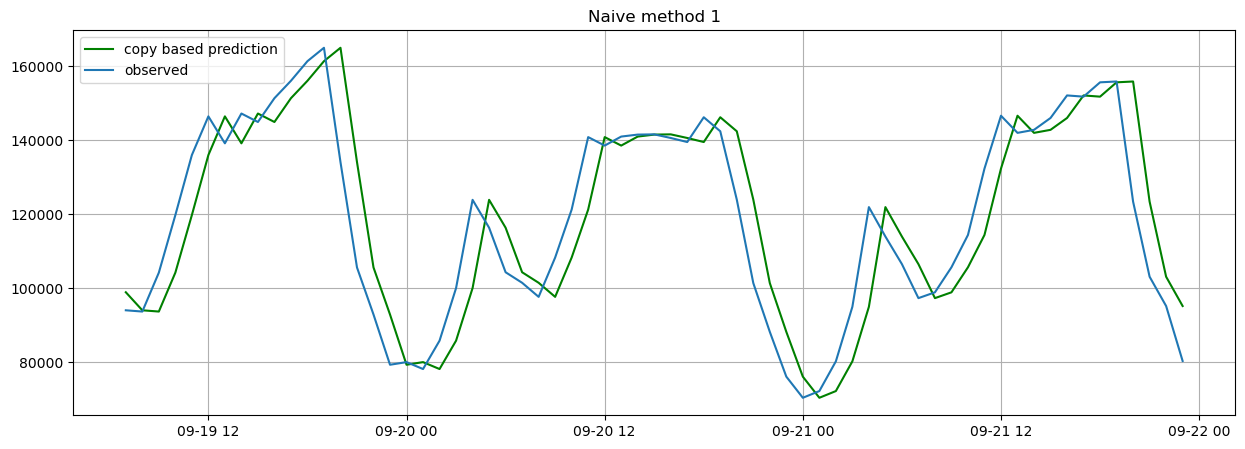

In [13]:
plotprediction(ads[ads_test_ix]['Ads'], ads[ads_test_ix]['copy_pred'], labels=['observed', 'copy based prediction'], title="Naive method 1")

Let's evaluate it

In [14]:
print_stats(ads[ads_test_ix]['Ads'], ads[ads_test_ix]['copy_pred'], "copy method")

copy method: 
	r^2=0.781031
	MAE=9378.384615
	MAPE=8.396050


Do this yourself on the other dataset

Hard to say much yet because it's only our first model, but you should notice that the first time series is much easier to fit than the second one. Let's move on to the next method!

We assume that the future value of our variable depends on the plain average of its k previous values. 
$$
y_t=\frac{1}{k}\sum_{n=1}^k y_{t−n}
$$
Can you implement a function that does that?

In [ ]:
import numpy as np  

def plain_moving_average(series, n):
    #write your code here ...
    return 


In [ ]:
ads['ma_pred']= plain_moving_average(ads['Ads'], 3)

In [ ]:
plotprediction(ads[ads_test_ix]['Ads'], ads[ads_test_ix]['ma_pred'], labels=['observed', 'rolling average window prediction'], title="Naive method 2")

In [ ]:
print_stats(ads[ads_test_ix]['Ads'], ads[ads_test_ix]['ma_pred'], "MA smoothing")


Don't forget to compare what you get with the previous model. 

Can you do the same with the currency dataset?

Clearly, we cannot make predictions too far in the future -- in order to get the value for the next step, we need the previous values to be actually observed. But plain moving average has another use case - smoothing the original time series to identify trends. As we saw previously, Pandas has an implementation available with DataFrame.rolling(window).mean(). The wider the window, the smoother the trend. In the case of very noisy data, which is often encountered in finance, this procedure can help detect common patterns.

Let's smooth the entire currency dataset by the previous 4 hours and 24 hours.

In [ ]:
plotprediction(currency['GEMS_GEMS_SPENT'], plain_moving_average(currency['GEMS_GEMS_SPENT'], 4), x_axis=currency.index, labels=['observed', 'moving average smoothing (p=4)'], title="Smoothing")
plotprediction(currency['GEMS_GEMS_SPENT'], plain_moving_average(currency['GEMS_GEMS_SPENT'], 24), x_axis=currency.index,labels=['observed', 'moving average smoothing (p=24)'], title="Smoothing")

You should notice the downside of our simple approach. With p=24, we are clearly missing most peaks (should we use much smaller p? should we check the ACF?). Let's try other approaches

-------------------

# Part 2 

# Autoregressive model

Shifting the series n steps back, we get a feature column where the current value of time series is aligned with its value at time t−n. You have done this before a couple of times. 

If we make a 1 lag shift and train a model on that feature, the model will be able to forecast 1 step ahead from having observed the current state of the series. Increasing the lag, say, up to 6, will allow the model to make predictions 6 steps ahead; however it will use data observed 6 steps back. If something fundamentally changes the series during that unobserved period, the model will not catch these changes and will return forecasts with a large error. Therefore, during the initial lag selection, one has to find a balance between the optimal prediction quality and the length of the forecasting horizon.

In [ ]:

# Creating a copy of the initial datagrame to make various transformations 
ads_data = pd.DataFrame(ads.Ads.copy())

There's a couple of very useful functions to determine Autocorrelation and Partial Autocorrelation

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ads_data['Ads'])

In [ ]:
plt.clf() 

In [ ]:
plot_pacf(ads_data['Ads'])

In [ ]:
plt.clf()

A common rule of thumb is to consider PACF for the AR degree - essentially find the N first lags that are above the confidence interval. Having this in mind, we will now assume AR(3) for the "ads" dataset.

An important note is that this rule is **just** an indication for the starting point. It is quite common that you need to try different values. 

In [ ]:
LAGS=3 # Adding the lag of the target variable up to 3 steps back. FEEL FREE to try other values
for i in range(1,LAGS+1):
    print("adding lag")
    ads_data["lag_{}".format(i)] = ads_data.Ads.shift(i)


# take a look at the new dataframe 
ads_data.tail(7)

Before using the classical statsmodels package for this, let's use our good old friend SKLEARN.

In [ ]:
from sklearn.linear_model import LinearRegression


y = ads_data.Ads
X = ads_data.drop(['Ads'], axis=1)

X_train, X_test, y_train, y_test = X[ads_train_ix], X[ads_test_ix], y[ads_train_ix], y[ads_test_ix]

X_train=X_train[LAGS:]  #because the first LAGS observations will have NaNs
y_train=y_train[LAGS:]

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred=lr.predict(X_test)

plotprediction(y_test, y_pred)


In [ ]:
print_stats(y_test, y_pred, "AR (3)")

It improves, right?  :-)

Let's do it now the easier way, which means using the ARIMA object of statsmodels package 

In [ ]:
# ARIMA example
from statsmodels.tsa.arima.model import ARIMA

As we discussed in the lecture, making 'one-step' forecasts on the test data is little less straightforward than in the SKLEARN models, because the predict() and forecast() functions of the ARIMA library take in time indexes (and not the 'independent variables' themselves) and assume that all the data is already present in the model object. 

We will show you two ways of making these 'one-step' forecasts. In the first case, we will iteratively keeping appending observations from the test data to the original training data (recall the one-step time-series validation figure from the lecture), and we will retrain or reestimate the model with ALL previous data. Here, if there are N test observations, we will have N models estimated, although we do not store all of them.

In the second case, we will keep appending data to make one step forecasts WITHOUT retraining the original model. Thus, in this case the model remains fixed and is based on the original training data set. This is the use case that you are more familiar with from our previous lectures, where we train a model based on training data and then apply it to test data. 

In [ ]:
# First, we train a simple AR model of degree 3 using the training data set (we use the ARIMA package and set the differencing to 0 and the MA degree to 0)
ads_data = pd.DataFrame(ads.Ads.copy())
data=ads_data[ads_train_ix]
model=ARIMA(data, order=(3, 0, 0))
AR=model.fit()
print(AR.summary())

Compare the coefficients above from our simple OLS estimation of the linear lagged variable model. Despite the violation of the OLS assumptions, our estimates should be roughly the same as before.   

In [ ]:
lr.coef_

### CASE 1: Retraining the model iteratively

In [ ]:
# First we compute one-step forecasts on the test data by iteratively retraining the model
preds=[]
for l in range(0,len(ads_data[ads_test_ix])):
    preds.append(AR.forecast()[0]) # Get a one-step forecast, this uses observed data from the previous intervals
    AR = AR.append(ads_data[len(data)+l:len(data)+l+1],refit=True) # Add next observation from the test data and refit the model
y_pred=preds

In [ ]:
# Let's visualize and compute errors
plotprediction(ads_data[ads_test_ix]['Ads'], y_pred)

In [ ]:
print_stats(y_test, preds, "AR(3)")

### CASE 2: Without retraining the model

In [ ]:
# First, as before we train a model with only the training data
ads_data = pd.DataFrame(ads.Ads.copy())
data=ads_data[ads_train_ix]
model=ARIMA(data, order=(3, 0, 0))
AR=model.fit()
print(AR.summary())

In [ ]:
# Next, we again compute the one-step forecasts, iteratively adding the test data one observation at a time, except we don't retrain the model
preds=[]
for l in range(0,len(ads_data[ads_test_ix])):
    preds.append(AR.forecast()[0]) # Get a one-step forecast, this uses observed data from the previous intervals
    AR = AR.append(ads_data[len(data)+l:len(data)+l+1],refit=False) # Add next observation from the test data but do not refit the model
y_pred=preds

In [ ]:
# Let's visualize and compute errors
plotprediction(ads_data[ads_test_ix]['Ads'], y_pred)

In [ ]:
print_stats(y_test, preds, "AR(3)")

### Multi-step forecasts and in-sample predictions

In [ ]:
# Note that you can also get easily get multistep forecasts 
# For example, the following gives you a 10 step prediction from the end of the data (since we appended all the data, this is a ten step forecast from the end of the training+test period)
AR.forecast(steps=10)

In [ ]:
# You can also get in-sample predictions (i.e. on the training data) using the predict function.
# For example, the following generates predictions between the period '2017-09-19 07:00:00' and '2017-09-20 07:00:00'.
# The dynamic=False option means that we use observed data from previous intervals to generate the predictions, thus the residuals can be computed from these
# The dynamic=True option is more like an in-sample multi-step forecast for the entire period from '2017-09-19 07:00:00' to '2017-09-20 07:00:00'
# You can see clearly that the dynamic = False will give you much better predictions.

AR.predict(start='2017-09-19 07:00:00',end='2017-09-20 07:00:00',dynamic=False)

In [ ]:
AR.predict(start='2017-09-19 07:00:00',end='2017-09-20 07:00:00',dynamic=True)

So, AR is generally an improvement. Do you want to do the same for the currency dataset? You can do the one-step forecasts by iteratively retraining the model.

# Adding moving average (MA) model component

Now let's move on to the MA component of our model. Again, the ACF result can help you guide yourself. What people do is select the degree by the number of first ACF correlations that are **clearly** above the confidence interval. Note that more complex ARIMA models can be sometimes difficult to estimate, in which case you can try with smaller degrees. 

Let's run the ACF/PACF code again 

In [ ]:
plot_acf(ads_data['Ads'])

In [ ]:
plt.clf()

In [ ]:
plot_pacf(ads_data['Ads'])

In [ ]:
plt.clf()

Should we try MA=1 to 3? You can keep the AR degree you chose from before, otherwise it'll be even harder to estimate. So, why not trying (3, 2), where AR=3 and MA=2?

In [ ]:
# First, as before we train a model with only the training data
ads_data = pd.DataFrame(ads.Ads.copy())
data=ads_data[ads_train_ix]
model=ARIMA(data, order=(3, 0, 2))
AR=model.fit()
print(AR.summary())

In [ ]:
preds=[]
for l in range(0,len(ads_data[ads_test_ix])):
    preds.append(AR.forecast()[0]) # Get a one-step forecast, this uses observed data from the previous intervals
    AR = AR.append(ads_data[len(data)+l:len(data)+l+1],refit=True) # Add next observation from the test data and refit the model
y_pred=preds

In [ ]:
plotprediction(y_test, y_pred)

In [ ]:
print_stats(y_test, y_pred, "ARMA (3,2)")

Hmmm... it didn't necessarily improve much! :-( Feel free to try other AR, MA degree combinations. 

Can you replicate the analysis with the currency dataset?

-------

# ARIMA

We finally arrived to the last model: the full ARIMA model, which has all components, of Auto Regressive (AR), Integration (I) and Moving Average (MA). 

A crucial question now relates to the I component. Is the data already stationary? Do we need to 
work on it?

The first thing to do is run the Augmented Dickey-Fuller (ADF) test 

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(ads['Ads'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
   print('\t%s: %.3f' % (key, value))

From ADF test, it's clear that the data is stationary enough not to need the I part. However, just for demonstration we'll fit a ARIMA(3, 1, 2) model. 

In [ ]:
# First, as before we train a model with only the training data
ads_data = pd.DataFrame(ads.Ads.copy())
data=ads_data[ads_train_ix]
model=ARIMA(data, order=(3, 1, 2))
AR=model.fit()
print(AR.summary())

Always pay attention to the p-values in this table. Whenever they have values very different than 0 (e.g >0.05), then you can consider removing that variable... You can try changing your parameters above accordigly. 

In [ ]:
preds=[]
for l in range(0,len(ads_data[ads_test_ix])):
    preds.append(AR.forecast()[0]) # Get a one-step forecast, this uses observed data from the previous intervals
    AR = AR.append(ads_data[len(data)+l:len(data)+l+1],refit=True) # Add next observation from the test data and refit the model
y_pred=preds

In [ ]:
#y_test=ads[ads_test_ix]['Ads']
plotprediction(y_test, y_pred)

In [ ]:
print_stats(y_test, y_pred)

Now, let's try with the currency data? 

Some tips:
- This time, the analysis may be quite different. So don't just replicate from above. Look at the results step by step
- It's possible that the best is to ignore findings from above (for example reducing the AR or MA degrees to get it to work)
- If you want to try multiple combinations, you should split the training dataset into train+development set
- You can make a brute-force approach (e.g. 3 for loops, one per p, q, d), and run it overnight... If you do this, you need to use a "try  ... except" block because your code will crash a few times.  

-------------

# Part 3

We're going now for the generic modeling tools (i.e. SKLEARN). The approach is to prepare the data so as to reflect the time series nature. You can use what you learned from above (e.g. AR degree). 

In [ ]:

# Creating a copy of the initial datagrame to make various transformations 
ads_data = pd.DataFrame(ads.Ads.copy())

Let's try a few... feel free to add whatever other models you like

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

We'll test them all in sequence and just see the results

In [ ]:

models=[GradientBoostingRegressor(), LinearRegression(), MLPRegressor()]


for md in models:
    print("\n\nTesting ", str(type(md)))
    preds=[]
    for l in ads_data[ads_test_ix]['Ads'].index:  #Just like with the ARIMA models, we're retraining the model each time 
                                          #we make a new prediction 
        data_extract=ads_data[ads_data.index<=l]
        LAGS=3        
        # Adding the lag of the target variable up to 6 steps back
        for i in range(1,LAGS+1):
            data_extract["lag_{}".format(i)] = data_extract.Ads.shift(i)
        data_extract=data_extract.dropna()
        y = data_extract['Ads'][:-1]
        X = data_extract.drop(['Ads'], axis=1)[:-1]

        md.fit(X, y)
        pred=md.predict(np.array(data_extract.drop(['Ads'], axis=1).iloc[-1], ndmin=2))
        preds.append(pred[0])

    y_pred = preds
    print_stats(y_test, y_pred, str(type(md)))

Do the results for the other dataset show the same pattern (of Gradient Boosting being the best, better than ARIMA also)?